# DDIM
>参考论文DENOISING DIFFUSION IMPLICIT MODELS

* 本文基于CIFAR-10训练
* 注意：在我的阅读过程中，发现很多记号并不和DDPM统一，很多部分的$\alpha_t$实际上是一个prod的量，在DDPM论文中写作$\overline{\alpha_t}$

## 简介

DDIM是一个non-Markovian process

其前向过程中，下一步的状态由本步状态及初始状态共同决定，有以下公式

与DDPM不同的是，在DDIM论文中加入了一个real vector:$\sigma$，$\sigma$用于控制噪声的量

$$
q_{\sigma}(x_{t}|x_{t-1}, x_0) = \mathcal{N}(\sqrt{\alpha_{t-1}}x_0 + \sqrt{1-\alpha{t-1}-\sigma^2}\cdot{\frac{x_t-\sqrt{\alpha_t}x_0}{\sqrt{1-\alpha_t}}}, \sigma^2_t I)
$$

前向过程也可以通过Byaes公式描述（具体略）

In [123]:
# coding:utf-8

import torch
import torch.nn as nn
import copy
import torch.nn.functional as F
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

* 本文基于CIFAR-10 dataset 训练

In [124]:
# load CIFAR-10 dataset

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 缩放到[-1, 1]范围
])

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("Dataset loaded successfully!")

d:\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Dataset loaded successfully!


In [125]:
# choose one type of data to train
target_class = 'ship'  # 选择要训练的类别
target_class_index = classes.index(target_class)  # 获取类别索引
print(f"Training on class: {target_class} (index: {target_class_index})")

class_indices = [i for i, label in enumerate(dataset.targets) if label == target_class_index]
subset = torch.utils.data.Subset(dataset, class_indices)
subset_dataloader = DataLoader(subset, batch_size=64, shuffle=True)
print(f"Number of samples for class '{target_class}': {len(subset)}")
print("shape of images:", subset[0][0].shape)  # 打印一张图像的形状

Training on class: ship (index: 8)
Number of samples for class 'ship': 5000
shape of images: torch.Size([3, 32, 32])


## DDIM的前向扩散过程

* 对上方对前向推导的公式进行变换，可得：

$$
x_{t-1} = \sqrt{\overline{\alpha}_{t-1}}x_0 + \sqrt{1-\overline{\alpha}_{t-1} - \sigma_t^2}\frac{x_t - \sqrt{\overline{\alpha}_t}x_0}{\sqrt{1-\overline{\alpha}_t}} + \sigma_t z, z \sim \mathcal{N}(0,I)
$$

不过在这个notebook里，我使用的是与DDPM相同的加噪

与DDPM类似，DDIM论文中的前向noise process也被设为一个$T=1000$的process，同时$\beta_1$，$\beta_t$，$\overline{\alpha}$等参量设置同DDPM相同，在这里我会将它写出来

In [126]:
beta_1 = 1e-4
beta_t = 0.02
T = 1000

betas = torch.linspace(beta_1, beta_t, T)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def alpha_bar_at(t):
    """
    获取 alpha_bar(t)。支持标量/批量 t。
    约定: t = -1 时返回 1，用于采样边界 x_0。
    t 其余取值按 [0, T-1] 截断。
    """
    if not torch.is_tensor(t):
        t = torch.tensor(t, dtype=torch.long)
    t = t.long()

    t_clamped = torch.clamp(t, 0, T - 1)
    vals = alpha_bars.to(t.device)[t_clamped]
    ones = torch.ones_like(vals, dtype=vals.dtype, device=vals.device)
    return torch.where(t >= 0, vals, ones)

In [127]:
def add_noise(x0, t, sigma=None):
    """
    训练用前向加噪: q(x_t|x_0)
    x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * eps
    """
    alpha_bar_t = alpha_bar_at(t).view(-1, 1, 1, 1).to(x0.device)
    noise = torch.randn_like(x0)
    x_t = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise
    return x_t, noise

## DDIM

在论文中$\sigma_{\tau_i}$是由随机性系数$\eta$和噪声系数$\alpha_{\tau_i}$共同决定，有以下公式

$$
    \sigma_{\tau_i}(\eta) = \eta\sqrt{\frac{1-\overline{\alpha}_{\tau_{i-1}}}{1-\overline{\alpha}_{\tau_i}}} \cdot \sqrt{\frac{1-\overline{\alpha}_{\tau_i}}{\overline{\alpha}_{\tau_{i-1}}}}
$$



In [128]:
def get_sigma_t(t, t_prev, eta):
    bar_alpha_t = alpha_bar_at(t).view(-1, 1, 1, 1).to(t.device)
    bar_alpha_prev = alpha_bar_at(t_prev).view(-1, 1, 1, 1).to(t.device)

    sigma2 = ((1 - bar_alpha_prev) / (1 - bar_alpha_t)) * (1 - bar_alpha_t / bar_alpha_prev)
    sigma2 = torch.clamp(sigma2, min=0.0)
    sigma_t = eta * torch.sqrt(sigma2)
    return sigma_t

核心函数，即DDIM的反向去噪函数，根据论文中的公式：

$$
x_{t-1} = \sqrt{\overline{\alpha}_{t-1}} (\frac{x_t - \sqrt{1-\overline{\alpha}_t} \epsilon_\theta^{(t)} (x_t) }{\sqrt{\overline{\alpha}_t}}) + \sqrt{1 - \overline{\alpha}_{t-1} - \sigma_t^2} \cdot \epsilon_\theta^{(t)}(x_t) + \sigma_t \epsilon_t
$$

去噪不一定是逐步的，$x_{t-1}$可以表示为一个向更小噪声时刻更新的过程

In [129]:
def DDIM(x_t, t, t_prev, predict_noise, sigma):
    """
    DDIM 反向采样一步: x_t -> x_{t_prev}
    """
    bar_alpha_t = alpha_bar_at(t).view(-1, 1, 1, 1).to(x_t.device)
    bar_alpha_prev = alpha_bar_at(t_prev).view(-1, 1, 1, 1).to(x_t.device)

    pred_x0 = (x_t - torch.sqrt(1 - bar_alpha_t) * predict_noise) / torch.sqrt(bar_alpha_t)
    direction = torch.sqrt(torch.clamp(1 - bar_alpha_prev - sigma**2, min=0.0)) * predict_noise
    random_noise = torch.randn_like(x_t)

    x_prev = torch.sqrt(bar_alpha_prev) * pred_x0 + direction + sigma * random_noise

    return x_prev

## 噪声预测神经网络

* 我使用的是UNet

In [130]:
# 时间编码
def time_embedding(t, embid_dim):
    # 支持标量时间步或批量时间步输入
    if not torch.is_tensor(t):
        t = torch.tensor(t, dtype=torch.float32)
    t = t.float()
    if t.dim() == 0:
        t = t.unsqueeze(0)
    if t.dim() == 1:
        t = t.unsqueeze(1)  # (B, 1)

    half_dim = embid_dim // 2
    device = t.device
    dtype = t.dtype

    freq = torch.arange(half_dim, device=device, dtype=dtype)
    freq = torch.exp(-torch.log(torch.tensor(10000.0, device=device, dtype=dtype)) * freq / max(half_dim - 1, 1))

    emb = t * freq.unsqueeze(0)
    emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)

    if embid_dim % 2 == 1:
        emb = F.pad(emb, (0, 1))

    return emb  # (B, embid_dim)

In [131]:
# 先定义残差网络用以进行上下采样
class ResNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_filters=64, time_emb_dim=128, time_emb = time_embedding, is_time_emb=True):
        super(ResNet, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, num_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(num_filters, num_filters, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(num_filters, out_channels, kernel_size=3, padding=1)

        self.time_emb = time_emb  # 时间步嵌入
        self.time_emb_dim = time_emb_dim
        self.time_emb_proj = nn.Linear(time_emb_dim, num_filters)
        self.is_time_emb = is_time_emb

        self.norm1 = nn.GroupNorm(8, num_filters)
        self.norm2 = nn.GroupNorm(8, num_filters)
        if out_channels % 8 != 0:   # 排除输出仅有3个通道的情况
            self.norm3 = nn.GroupNorm(1, out_channels)
        else:
            self.norm3 = nn.GroupNorm(8, out_channels)
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)   # 1x1卷积调整通道数
        self.act = nn.ReLU()

    def forward(self, x, t):
        # x: (B, C, H, W)
        # t: (B,) or (B, 1)
        t_emb = self.time_emb(t, self.time_emb_dim)  # (B, time_emb_dim)
        t_emb = self.time_emb_proj(t_emb)
        t_emb = t_emb.unsqueeze(-1).unsqueeze(-1)  # (B, num_filters, 1, 1)
        residual = self.skip(x)
        x = self.conv1(x)
        x = self.norm1(x)
        if self.is_time_emb:
            x = self.act(x + t_emb)  # 加入time embedding
        else:
            x = self.act(x)
        x = self.conv2(x)
        x = self.norm2(x)
        x = self.act(x)
        x = self.conv3(x)
        x = self.norm3(x)
        return self.act(x) + residual  # 残差连接

In [132]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_filters=64, time_emb_dim=128, time_emb = time_embedding):
        super(UNet, self).__init__()
        # 下采样
        self.down1 = ResNet(in_channels, num_filters, num_filters, time_emb_dim, time_emb)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = ResNet(num_filters, num_filters * 2, num_filters * 2, time_emb_dim, time_emb)
        self.pool2 = nn.MaxPool2d(2) 
        # 中间层
        self.mld1 = ResNet(num_filters * 2, num_filters * 2, num_filters * 2, time_emb_dim, time_emb) 
        self.mld2 = ResNet(num_filters * 2, num_filters * 2, num_filters * 2, time_emb_dim, time_emb) 
        # 上采样
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up_block1 = ResNet(num_filters * 4, num_filters, num_filters, time_emb_dim, time_emb)
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up_block2 = ResNet(num_filters * 2, num_filters, num_filters, time_emb_dim, time_emb)

        self.out_conv = nn.Conv2d(num_filters, out_channels, kernel_size=1)

    def forward(self, x, t):
        s1 = self.down1(x, t)  # (B, num_filters, H, W)
        d1 = self.pool1(s1)  # (B, num_filters, H/2, W/2)
        s2 = self.down2(d1, t)  # (B, num_filters*2, H/2, W/2)
        d2 = self.pool2(s2)  # (B, num_filters*2, H/2, W/2)

        m = self.mld1(d2, t)  # (B, num_filters*2, H/2, W/2)
        m = self.mld2(m, t)  # (B, num_filters*2, H/2, W/2)
        
        u1 = self.up1(m)  # (B, num_filters, H/2, W/2)
        u1 = torch.cat([u1, s2], dim=1)  # (B, num_filters*3, H/2, W/2)
        u1 = self.up_block1(u1, t)  # (B, num_filters, H, W)
        u2 = self.up2(u1)  # (B, out_channels, H, W)
        u2 = torch.cat([u2, s1], dim=1)  # (B, num_filters*2, H, W)
        u2 = self.up_block2(u2, t)  # (B, out_channels, H, W)
        return self.out_conv(u2)


## 模型构建及训练

DDIM的反向去噪的时间步是在所有的时间步中取样而得的

In [140]:
div_T = 10  # 训练时的时间步间隔
T_tow = torch.arange(0, T, div_T)  # 训练时使用的时间步列表

In [ ]:
model = UNet(in_channels=3, out_channels=3, num_filters=64, time_emb_dim=128).to('cuda')

In [135]:
def generate_image(model, T=T_tow, eta=0.0):
    model.eval()
    with torch.no_grad():
        x_t = torch.randn(1, 3, 32, 32).to('cuda')
        for i in range(len(T) - 1, -1, -1):
            t_val = int(T[i].item())
            t_prev_val = int(T[i - 1].item()) if i > 0 else -1

            t_batch = torch.full((1,), t_val, dtype=torch.long, device=x_t.device)
            t_prev_batch = torch.full((1,), t_prev_val, dtype=torch.long, device=x_t.device)

            predict_noise = model(x_t, t_batch)
            sigma_t = get_sigma_t(t_batch, t_prev_batch, eta)
            x_t = DDIM(x_t, t_batch, t_prev_batch, predict_noise, sigma_t)

        x_t = (x_t.clamp(-1, 1) + 1) / 2
        return x_t.cpu().squeeze(0).permute(1, 2, 0).numpy()


def show_sample_images(epoch, model, T=T_tow, eta=0.0, num_samples=4):
    plt.figure(figsize=(8, 2))
    plt.title(f"Sample Images at Epoch {epoch}")
    plt.axis('off')
    for i in range(num_samples):
        img = generate_image(model, T, eta)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

In [136]:
# 余弦退火学习率
epochs = 100
warmup_epochs = 10

def cosine_annealing_with_warmup(step, total_steps=epochs, warmup_steps=warmup_epochs, lr_max=1e-3, lr_min=1e-6):
    """Cosine annealing learning rate scheduler with linear warmup."""
    if step < warmup_steps: # 线性warmup，前期学习率维持高位
        return lr_max
    else:
        # Cosine annealing
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * progress))

Epoch [1/100], Loss: 0.2694
Epoch [2/100], Loss: 0.0592
Epoch [3/100], Loss: 0.0467
Epoch [4/100], Loss: 0.0417
Epoch [5/100], Loss: 0.0412
Epoch [6/100], Loss: 0.0415
Epoch [7/100], Loss: 0.0398
Epoch [8/100], Loss: 0.0390
Epoch [9/100], Loss: 0.0368
Epoch [10/100], Loss: 0.0360
Epoch [11/100], Loss: 0.0355
Epoch [12/100], Loss: 0.0378
Epoch [13/100], Loss: 0.0358
Epoch [14/100], Loss: 0.0353
Epoch [15/100], Loss: 0.0341
Epoch [16/100], Loss: 0.0344
Epoch [17/100], Loss: 0.0357
Epoch [18/100], Loss: 0.0342
Epoch [19/100], Loss: 0.0343
Epoch [20/100], Loss: 0.0332


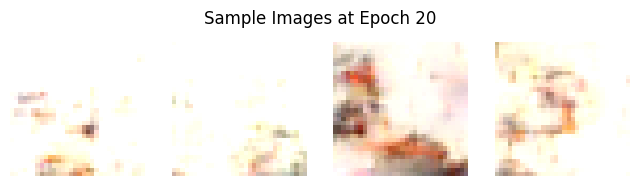

Epoch [21/100], Loss: 0.0309
Epoch [22/100], Loss: 0.0331
Epoch [23/100], Loss: 0.0333
Epoch [24/100], Loss: 0.0319
Epoch [25/100], Loss: 0.0318
Epoch [26/100], Loss: 0.0335
Epoch [27/100], Loss: 0.0321
Epoch [28/100], Loss: 0.0320
Epoch [29/100], Loss: 0.0291
Epoch [30/100], Loss: 0.0332
Epoch [31/100], Loss: 0.0309
Epoch [32/100], Loss: 0.0320
Epoch [33/100], Loss: 0.0313
Epoch [34/100], Loss: 0.0292
Epoch [35/100], Loss: 0.0303
Epoch [36/100], Loss: 0.0311
Epoch [37/100], Loss: 0.0300
Epoch [38/100], Loss: 0.0328
Epoch [39/100], Loss: 0.0306
Epoch [40/100], Loss: 0.0332


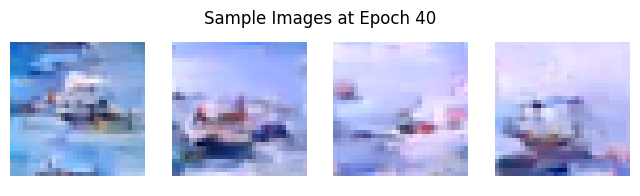

Epoch [41/100], Loss: 0.0310
Epoch [42/100], Loss: 0.0303
Epoch [43/100], Loss: 0.0302
Epoch [44/100], Loss: 0.0311
Epoch [45/100], Loss: 0.0298
Epoch [46/100], Loss: 0.0318
Epoch [47/100], Loss: 0.0312
Epoch [48/100], Loss: 0.0307
Epoch [49/100], Loss: 0.0297
Epoch [50/100], Loss: 0.0294
Epoch [51/100], Loss: 0.0289
Epoch [52/100], Loss: 0.0314
Epoch [53/100], Loss: 0.0286
Epoch [54/100], Loss: 0.0295
Epoch [55/100], Loss: 0.0302
Epoch [56/100], Loss: 0.0323
Epoch [57/100], Loss: 0.0309
Epoch [58/100], Loss: 0.0281
Epoch [59/100], Loss: 0.0280
Epoch [60/100], Loss: 0.0293


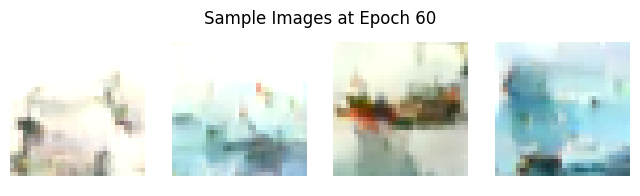

Epoch [61/100], Loss: 0.0293
Epoch [62/100], Loss: 0.0299
Epoch [63/100], Loss: 0.0281
Epoch [64/100], Loss: 0.0281
Epoch [65/100], Loss: 0.0287
Epoch [66/100], Loss: 0.0289
Epoch [67/100], Loss: 0.0290
Epoch [68/100], Loss: 0.0288
Epoch [69/100], Loss: 0.0302
Epoch [70/100], Loss: 0.0296
Epoch [71/100], Loss: 0.0290
Epoch [72/100], Loss: 0.0289
Epoch [73/100], Loss: 0.0288
Epoch [74/100], Loss: 0.0292
Epoch [75/100], Loss: 0.0304
Epoch [76/100], Loss: 0.0298
Epoch [77/100], Loss: 0.0290
Epoch [78/100], Loss: 0.0290
Epoch [79/100], Loss: 0.0269
Epoch [80/100], Loss: 0.0291


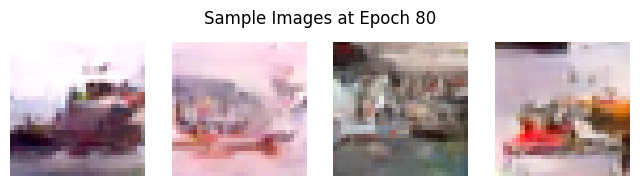

Epoch [81/100], Loss: 0.0298
Epoch [82/100], Loss: 0.0271
Epoch [83/100], Loss: 0.0292
Epoch [84/100], Loss: 0.0271
Epoch [85/100], Loss: 0.0277
Epoch [86/100], Loss: 0.0288
Epoch [87/100], Loss: 0.0285
Epoch [88/100], Loss: 0.0275
Epoch [89/100], Loss: 0.0287
Epoch [90/100], Loss: 0.0278
Epoch [91/100], Loss: 0.0282
Epoch [92/100], Loss: 0.0275
Epoch [93/100], Loss: 0.0267
Epoch [94/100], Loss: 0.0283
Epoch [95/100], Loss: 0.0282
Epoch [96/100], Loss: 0.0274
Epoch [97/100], Loss: 0.0275
Epoch [98/100], Loss: 0.0277
Epoch [99/100], Loss: 0.0296
Epoch [100/100], Loss: 0.0284


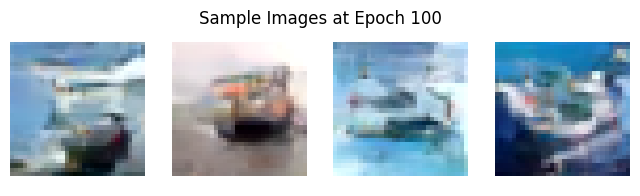

In [137]:
# 训练模型

optimizer = optim.Adam(model.parameters(), lr=5e-4)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_idx, (images, _) in enumerate(subset_dataloader):
        images = images.to('cuda')
        batch_size = images.size(0)

        # 随机采样时间步t
        t = torch.randint(0, T+1, (batch_size,), device=images.device)

        # 训练条件时间与实际加噪时间保持一致
        noisy_images, noise = add_noise(images, t)

        optimizer.zero_grad()
        predicted_noise = model(noisy_images, t)
        loss = F.mse_loss(predicted_noise, noise)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(subset_dataloader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    # 更新学习率
    lr = cosine_annealing_with_warmup(epoch, total_steps=epochs, warmup_steps=warmup_epochs)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    if (epoch + 1) % 20 == 0:  # 每20个epoch展示一次生成的图像
        show_sample_images(epoch + 1, model, T=T_tow, eta=0.0, num_samples=4)

# show_sample_images(model, T=T_tow, eta=0.0, num_samples=4)

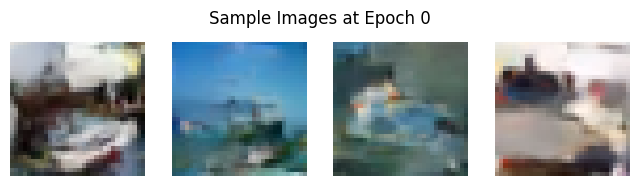

In [143]:
show_sample_images(0, model, T=T_tow, eta=0.0, num_samples=4)